El código para graficar la eof y calcularla lo obtuve de un ejemplo de la página web de la librería que use para calcular la eof: https://ajdawson.github.io/eofs/examples/nao_xarray.html

In [3]:
import numpy as np
import pandas as pd

import xarray as xr
from eofs.xarray import Eof

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

import os

Creo un nuevo mapa de color para que los datos cercanos a 0 sean completamente blancos

In [4]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

bwr = mpl.colormaps['bwr'].resampled(40)
newcolors = bwr(np.linspace(0, 1, 40))
white = np.array([256/256, 256/256, 256/256, 1])
newcolors[17:23, :] = white
newcmp = ListedColormap(newcolors)

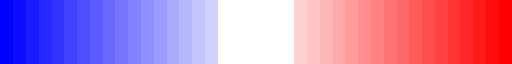

In [5]:
newcmp

# Slice the data depending of the months

In [21]:
def Slice_netcdf(file, months): # hemisph(0=north, 1=south)
    
    ds = xr.open_dataset(file)

    
    hgt = ds['hgt'].values
    time = ds['time'].values
    lon = ds['lon'].values
    lat = ds['lat'].values
    level = ds['level'].values

    years = int(len(time)/12)

    hgt = hgt.reshape((years, 12, 1, 29, 144))

    time = time.reshape((years,12))

    hgt_season = hgt[:, months, :, :, :]  # (años, meses, level, lat, lon)
    time = time[:, months]

    hgt_season = hgt_season.reshape((years * len(months), 1, 29, 144))

    time = time.reshape(years  * len(months))

    HGT = xr.DataArray(
        data=hgt_season,
        dims=["time", 'level', "lat", "lon"],
        coords=dict(
            time=time,
            lon=lon,
            lat=lat,
            level=level))

    return HGT

# Calculate the EOF

In [17]:
def Calc_eof(HGT):
    #HGT = HGT - HGT.mean(dim='time')

    # Create an EOF solver to do the EOF analysis. Square-root of cosine of
    # latitude weights are applied before the computation of EOFs.
    coslat = np.cos(np.deg2rad(HGT.coords['lat'].values)).clip(0., 1.)
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(HGT, weights=wgts)
    
    # Retrieve the leading EOF, expressed as the covariance between the leading PC
    # time series and the input SLP anomalies at each grid point.
    eof = solver.eofsAsCorrelation(neofs=1)

    return eof

# Slice data for Alta-Baja

In [85]:
def Slice_flux(data, months):

    date = data['Date'].values
    flux = data['flux'].values

    years = int(len(date)/12)

    date = date.reshape((years, 12))

    flux = flux.reshape((years,12))

    date_sliced = date[:, months]  # (años, meses)
    flux = flux[:, months]

    date_sliced = date_sliced.reshape((years * len(months)))
    flux = flux.reshape(years  * len(months))

    flux_sliced = xr.DataArray(
        data=flux,
        dims=["Date"],
        coords=dict(
            Date=date_sliced))

    return flux_sliced

# Plot a single EOF

In [19]:
def Graph_eof(eof, file, months):

    ################################# Periodic Conditions: ###################################

    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    
    ############################ Plot the EOF expressed as covariance ##########################
    
    clevs = np.linspace(-1, 1, 41)
    
    if ("N" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)    

    elif ("S" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        
    ax = plt.axes(projection=proj)
    ax.coastlines()1948
    ax.set_global()
    
    eof.plot.contourf(ax=ax, levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=True)

    
    ax.set_title(f'EOF expressed as correlation {file} {months}', fontsize=16)
    plt.savefig(f"Plots/{file} {months}.png")
    
    plt.show()

    ################################################################################################

# Main

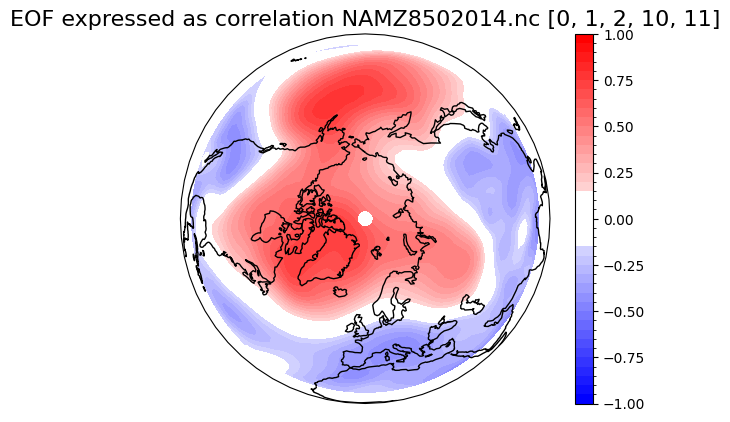

In [22]:
flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2015")].reset_index().to_xarray()

HGT = Slice_netcdf("NAMZ8502014.nc", [0,1,2,10,11])   # North
            
flux = Slice_flux(flux_data, [0,1,2,10,11])
alta = flux[((flux - flux.mean()) / flux.std()) <= -1]["Date"].values
HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)

eof = Calc_eof(HGT_alta)

Graph_eof(eof, "NAMZ8502014.nc", [0,1,2,10,11])

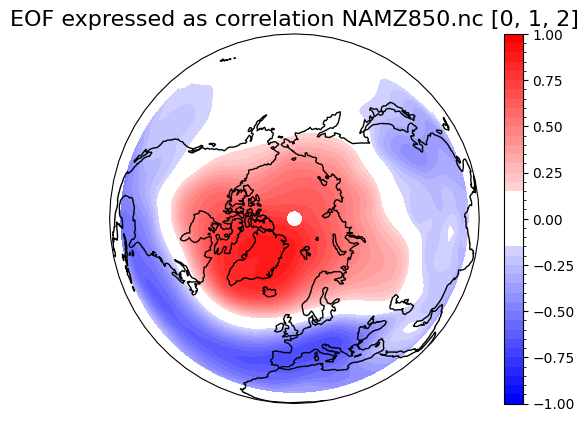

In [23]:
HGT = Slice_netcdf("NAMZ8502014.nc", [0,1,2,10,11])   # North

eof = Calc_eof(HGT)

Graph_eof(eof, "NAMZ850.nc", [0,1,2])

In [ ]:
flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2025")].reset_index().to_xarray()

directory = os.scandir("./AMZ")

eofs = []
files = []
all_months = []
months_name = []

p_months_north = {"ene-mar":[0,1,2], "jun-ago":[5,6,7]}
p_months_south = {"nov":[10], "jun-ago":[5,6,7], "feb-mar":[1,2]}

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
            
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            eofs.append(Calc_eof(HGT))
            files.append(amz.name)
            all_months.append(p_months_north[months])
            months_name.append(months)


directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South
            eofs.append(Calc_eof(HGT))
            files.append(amz.name)
            all_months.append(p_months_south[months])
            months_name.append(months)


###################################################################################################################
###################################################################################################################

###################
##### ALTA ########
###################

directory = os.scandir("./AMZ")

eofs_alta = []

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
            
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eofs_alta.append(Calc_eof(HGT_alta))


directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eofs_alta.append(Calc_eof(HGT))

###################################################################################################################
###################################################################################################################

###################
##### BAJA ########
###################

directory = os.scandir("./AMZ")

eofs_baja = []

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
            
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eofs_baja.append(Calc_eof(HGT_baja))


directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            1948
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # North
            
            flux = Slice_flux(flux_data, p_months_south[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eofs_baja.append(Calc_eof(HGT_baja))

# North

In [76]:
p_months_north = {"Ene-Mar":[0,1,2], "Jun-Ago":[5,6,7]} # Meses de interés

### NAMZ850 1948-2024

In [ ]:
# First we calculate the eof's
# Normal:
file = "AMZ/NAMZ850.nc"

for months in p_months_north.keys():
            
    HGT = Slice_netcdf(file, p_months_north[months])   # North
    eofs.append(Calc_eof(HGT))
    files.append(amz.name)
    all_months.append(p_months_north[months])
    months_name.append(months)

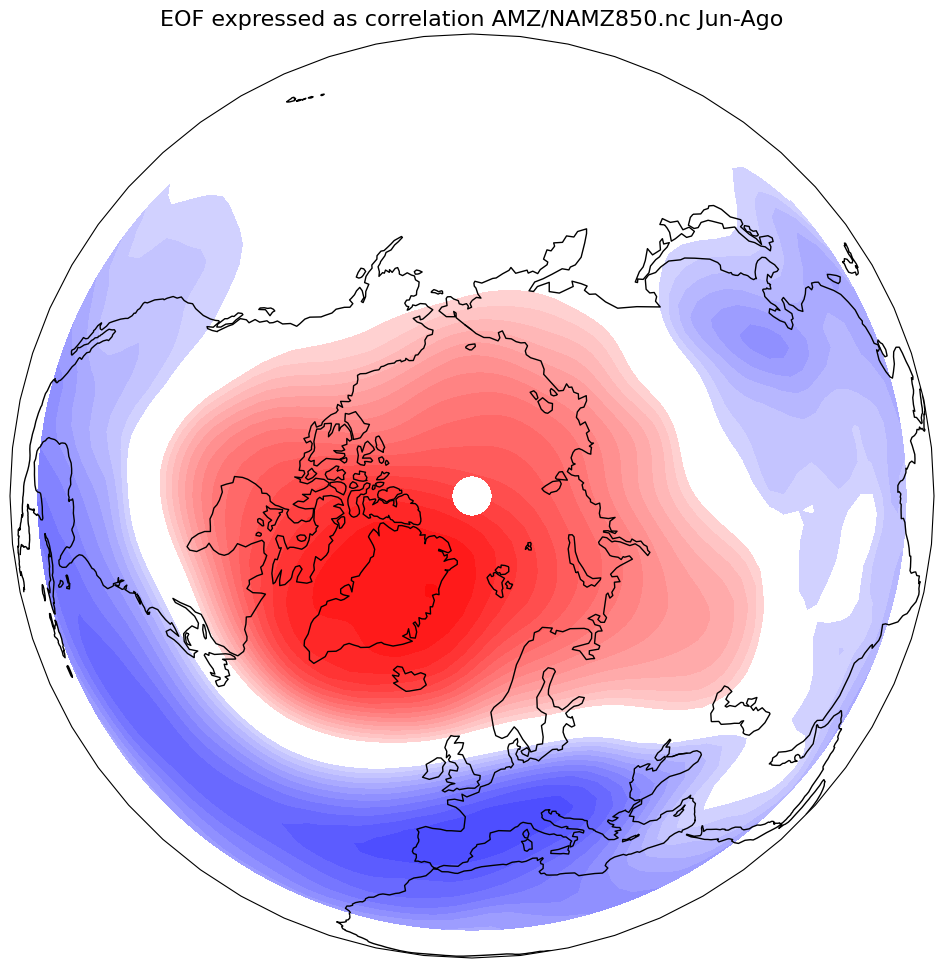

In [63]:
fig = plt.figure(figsize=(18,12))

HGT = Slice_netcdf(file, [0,1,2,10,11])   # North

eof = Calc_eof(HGT)


################################# Periodic Conditions: ###################################

lat = eof["lat"].values
lon = eof["lon"].values
eof_aux = eof.values[0][0]

eof_dat = np.zeros([29,145])
eof_dat[:,:144] = eof_aux
eof_dat[:,144] = eof_aux[:,0]

lon = np.append(lon, 360)

eof = xr.DataArray(
                    data=eof_dat,
                    dims=["lat", "lon"],
                    coords=dict(lon=lon, lat=lat))

############################################################################################


############################ Plot the EOF expressed as covariance ##########################

clevs = np.linspace(-1, 1, 41)


proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)  
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.coastlines()
ax.set_global()

cs = eof.plot.contourf(ax=ax, levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)


ax.set_title(f'EOF expressed as correlation {file} {months}', fontsize=16)
#plt.savefig(f"Plots/{file} {months}.png")

plt.show()


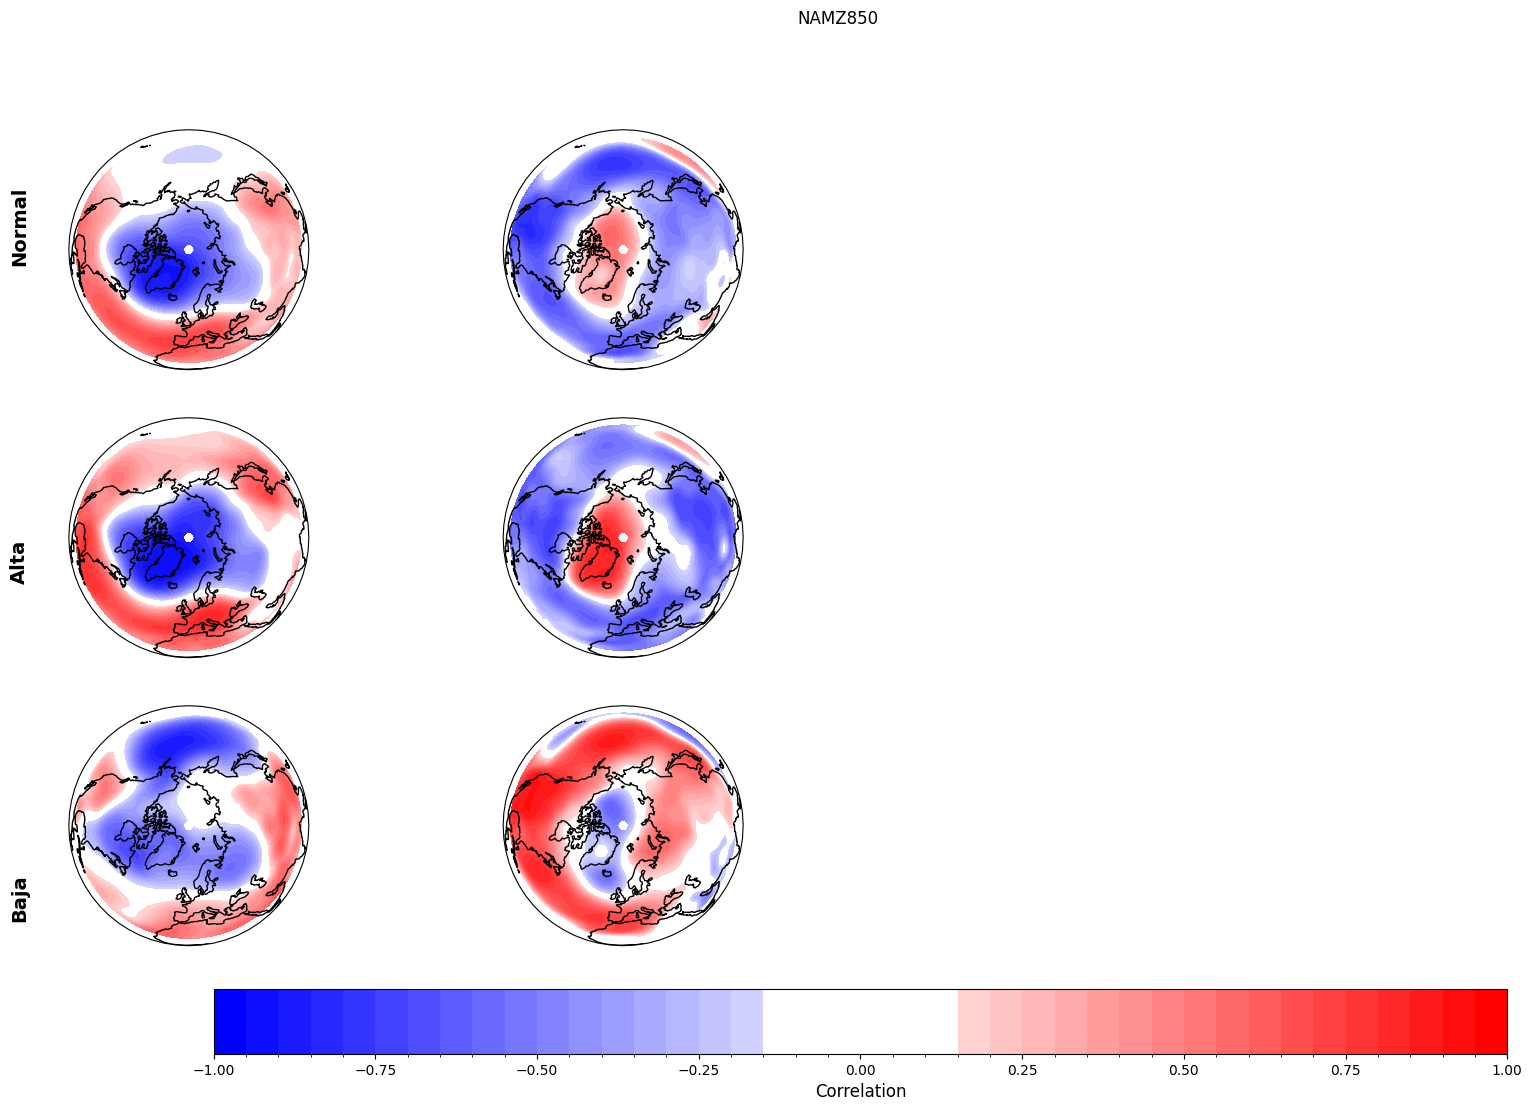

In [168]:
file = "AMZ/NAMZ850.nc"

fig, axs = plt.subplots(3, 2, figsize=(18,12), subplot_kw={'projection': ccrs.Orthographic(central_longitude=0, central_latitude=90)})

j = 0

# Normal:
for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
    eof = Calc_eof(HGT)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)

j += 1

###############################################################################################
#####################             FLUX 10.7          ##########################################
###############################################################################################

flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2025")].reset_index().to_xarray()

# Alta

for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
            
    flux = Slice_flux(flux_data, p_months_north[months])
    alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
    HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
    
    eof = -Calc_eof(HGT_alta)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)

j += 1

# Baja

for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
            
    flux = Slice_flux(flux_data, p_months_north[months])
    alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
    HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
    
    eof = -Calc_eof(HGT_alta)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)
    

cbar = fig.colorbar(cs, ax=axs, orientation="horizontal", fraction=0.07, pad=0.07)
cbar.set_label("Correlation", fontsize=12)
fig.suptitle("NAMZ850")

plt.subplots_adjust(left=-0.08, bottom=0.2, right=0.6, top=None, wspace=-0.45, hspace=None)


# Posiciones verticales aproximadas para 3 filas
y_positions = [0.80, 0.52, 0.24]   # ajustá según tu figura
row_titles = ["Normal", "Alta", "Baja"]  # Ejemplo de títulos por fila

for y, title in zip(y_positions, row_titles):
    fig.text(0.04, y, title, va='center', ha='left', fontsize=14, fontweight='bold', rotation=90)

plt.savefig("NAMZ850.pdf")
plt.show()

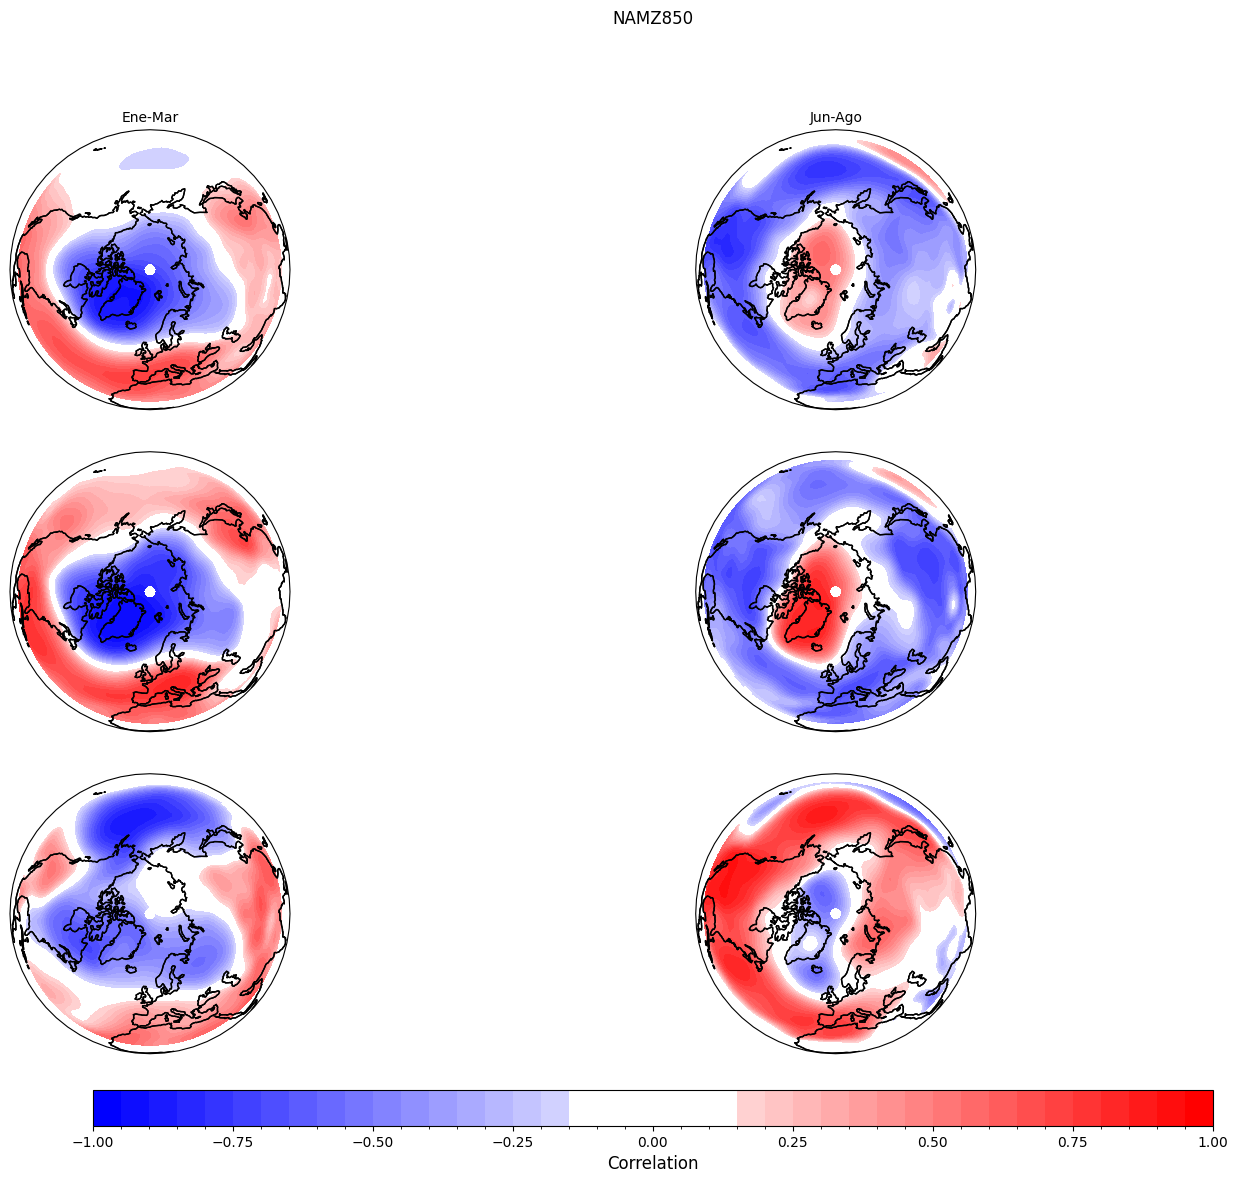

In [170]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs

fig = plt.figure(figsize=(16, 12))  # puedes ajustar el ancho total

# GridSpec con columnas más angostas para reducir espacio entre proyecciones
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[1, 1],   # proporción igual
    left = -0.1,
    wspace=-0.25,          # valor negativo -> columnas se empalman más
    hspace=0.15
)

axs = []
for r in range(3):
    row_axes = []
    for c in range(2):
        ax = fig.add_subplot(gs[r, c], projection=ccrs.Orthographic(central_longitude=0, central_latitude=90))
        ax.set_global()
        ax.coastlines()
        row_axes.append(ax)
    axs.append(row_axes)

axs = np.array(axs)  # para mantener la misma estructura axs[row][col]

# Aquí dibujarías tus mapas en cada axs[r][c] como antes
j = 0

# Normal:
for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
    eof = Calc_eof(HGT)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)
    
    axs[j][i].set_title(f'{months}', fontsize=10)

j += 1

###############################################################################################
#####################             FLUX 10.7          ##########################################
###############################################################################################

flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2025")].reset_index().to_xarray()

# Alta

for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
            
    flux = Slice_flux(flux_data, p_months_north[months])
    alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
    HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
    
    eof = -Calc_eof(HGT_alta)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)

j += 1

# Baja

for months, i in zip(p_months_north.keys(), range(2)):
    
    ################################# Calculate the EOF: ###################################
    HGT = Slice_netcdf(file, p_months_north[months])   # North
            
    flux = Slice_flux(flux_data, p_months_north[months])
    alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
    HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
    
    eof = -Calc_eof(HGT_alta)
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    axs[j][i].coastlines()
    axs[j][i].set_global()

    clevs = np.linspace(-1, 1, 41)
    cs = eof.plot.contourf(ax=axs[j][i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)

# Barra de color manual para evitar que dependa del tamaño de los axes
cax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(cs, cax=cax, orientation='horizontal')
cbar.set_label("Correlation", fontsize=12)

fig.suptitle("NAMZ850")
plt.savefig("NAMZ850_compacto.pdf")
plt.show()


# Plotting multiple plots in a single plot

I didn't create a function for this because the position of the plots can't be automatized (or I didn't found the way), so it doesn't make sense to create a function.

In [ ]:
fig = plt.figure(figsize=(18,12))

axs = []

for i in range(len(eofs)):


    ################################# Periodic Conditions: ###################################

    lat = eofs[i]["lat"].values
    lon = eofs[i]["lon"].values
    eof_aux = eofs[i].values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    if ("N" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)  
        ax = fig.add_subplot(4, 2, i+1, projection=proj)
        axs.append(ax)

    elif ("S" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        ax = fig.add_subplot(4, 3, 3+i, projection=proj)
        axs.append(ax)
    
    axs[i].coastlines()
    axs[i].set_global()

    clevs = np.linspace(-1, 1, 11)
    cs = eof.plot.contourf(ax=axs[i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)
    
    axs[i].set_title(f'EOF as correlation {files[i]} {months_name[i]}', fontsize=10)

cbar = fig.colorbar(cs, ax=axs, orientation="horizontal", fraction=0.05, pad=0.07)

cbar.set_label("Correlation", fontsize=12)

fig.suptitle("EOF for different hemispheres and altitude")

plt.savefig("MultiPlots.pdf")

plt.show()

# Plot ALTA

In [ ]:
fig = plt.figure(figsize=(18,12))

axs = []

for i in range(len(eofs_alta)):


    ################################# Periodic Conditions: ###################################

    lat = eofs_alta[i]["lat"].values
    lon = eofs_alta[i]["lon"].values
    eof_aux = eofs_alta[i].values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    if ("N" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)  
        ax = fig.add_subplot(4, 2, i+1, projection=proj)
        axs.append(ax)

    elif ("S" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        ax = fig.add_subplot(4, 3, 3+i, projection=proj)
        axs.append(ax)
    
    axs[i].coastlines()
    axs[i].set_global()

    clevs = np.linspace(-1, 1, 11)
    cs = eof.plot.contourf(ax=axs[i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)
    
    axs[i].set_title(f'EOF as correlation {files[i]} {months_name[i]}', fontsize=10)

cbar = fig.colorbar(cs, ax=axs, orientation="horizontal", fraction=0.05, pad=0.07)

cbar.set_label("Correlation", fontsize=12)

fig.suptitle("EOF for different hemispheres and altitude (ALTA)")

plt.savefig("MultiPlots_alta.pdf")

plt.show()

# Plot BAJA

In [ ]:
fig = plt.figure(figsize=(18,12))

axs = []

for i in range(len(eofs_baja)):


    ################################# Periodic Conditions: ###################################

    lat = eofs_baja[i]["lat"].values
    lon = eofs_baja[i]["lon"].values
    eof_aux = eofs_baja[i].values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################################################################################

    if ("N" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)  
        ax = fig.add_subplot(4, 2, i+1, projection=proj)
        axs.append(ax)

    elif ("S" in files[i]):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        ax = fig.add_subplot(4, 3, 3+i, projection=proj)
        axs.append(ax)
    
    axs[i].coastlines()
    axs[i].set_global()

    clevs = np.linspace(-1, 1, 11)
    cs = eof.plot.contourf(ax=axs[i], levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)
    
    axs[i].set_title(f'EOF as correlation {files[i]} {months_name[i]}', fontsize=10)

cbar = fig.colorbar(cs, ax=axs, orientation="horizontal", fraction=0.05, pad=0.07)

cbar.set_label("Correlation", fontsize=12)

fig.suptitle("EOF for different hemispheres and altitude (BAJA)")

plt.savefig("MultiPlots_baja.pdf")
plt.show()

In [91]:
ds = xr.open_dataset("NAMZ8502014.nc")
ds

<xarray.Dataset> Size: 13MB
Dimensions:  (time: 804, level: 1, lat: 29, lon: 144)
Coordinates:
  * lat      (lat) float32 116B 90.0 87.5 85.0 82.5 80.0 ... 27.5 25.0 22.5 20.0
  * level    (level) float32 4B 850.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 6kB 1948-01-01 1948-02-01 ... 2014-12-01
Data variables:
    hgt      (time, level, lat, lon) float32 13MB ...
Attributes:
    description:   Data from NCEP initialized reanalysis (4x/day).  These are...
    platform:     Model
    Conventions:  COARDS
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...
    NCO:          4.2.6
    history:      Fri Aug 21 17:47:52 2015: ncks -O -d level,850.000000 -d la...
    title:        monthly mean hgt from the NCEP Reanalysis